## Семестровая работа

#### Вариант 1

Изучите сортировку вставками и реализуйте ее в виде функции insertion_sort(some_list). Функция принимает список и сортирует его по возрастанию.
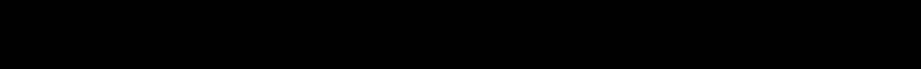
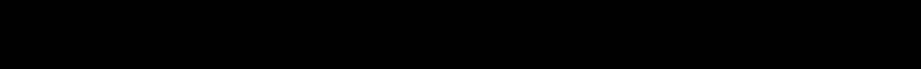
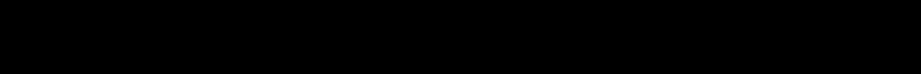
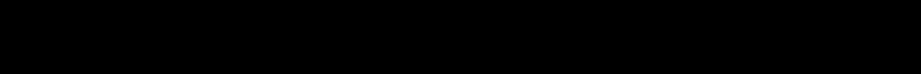

1.  (3 балла) Выпишите состояние списка [7, 3, 9, 4, 2, 5, 6, 1, 8] после каждой итерации алгоритма сортировки вставками. Сколько сравнений и перестановок было выполнено?

In [11]:

def insertion_sort(some_list):
    swaps = 0
    comparisons = 0
    for i in range(1, len(some_list)):
        print(f"Итерация {i} :", some_list)
        for j in range(i, 0, -1):
            comparisons += 1
            if some_list[j] < some_list[j - 1]:
                some_list[j - 1], some_list[j] = some_list[j], some_list[j-1]
                swaps += 1
            else:
                break
    print("Итого перестановок ", swaps)
    print("Итого сравнений ", comparisons)
    return some_list

print(insertion_sort([7, 3, 9, 4, 2, 5, 6, 1, 8]))



Итерация 1 : [7, 3, 9, 4, 2, 5, 6, 1, 8]
Итерация 2 : [3, 7, 9, 4, 2, 5, 6, 1, 8]
Итерация 3 : [3, 7, 9, 4, 2, 5, 6, 1, 8]
Итерация 4 : [3, 4, 7, 9, 2, 5, 6, 1, 8]
Итерация 5 : [2, 3, 4, 7, 9, 5, 6, 1, 8]
Итерация 6 : [2, 3, 4, 5, 7, 9, 6, 1, 8]
Итерация 7 : [2, 3, 4, 5, 6, 7, 9, 1, 8]
Итерация 8 : [1, 2, 3, 4, 5, 6, 7, 9, 8]
Итого перестановок  19
Итого сравнений  24
[1, 2, 3, 4, 5, 6, 7, 8, 9]


2.  (3 балла) Выпишите состояние списка [3, 5, 2, 9, 8, 1, 6, 4, 7] после каждой итерации алгоритма сортировки вставками. Сколько сравнений и перестановок было выполнено?
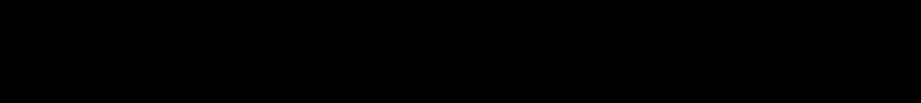

In [12]:
insertion_sort([3, 5, 2, 9, 8, 1, 6, 4, 7])

Итерация 1 : [3, 5, 2, 9, 8, 1, 6, 4, 7]
Итерация 2 : [3, 5, 2, 9, 8, 1, 6, 4, 7]
Итерация 3 : [2, 3, 5, 9, 8, 1, 6, 4, 7]
Итерация 4 : [2, 3, 5, 9, 8, 1, 6, 4, 7]
Итерация 5 : [2, 3, 5, 8, 9, 1, 6, 4, 7]
Итерация 6 : [1, 2, 3, 5, 8, 9, 6, 4, 7]
Итерация 7 : [1, 2, 3, 5, 6, 8, 9, 4, 7]
Итерация 8 : [1, 2, 3, 4, 5, 6, 8, 9, 7]
Итого перестановок  16
Итого сравнений  22


[1, 2, 3, 4, 5, 6, 7, 8, 9]

3.  (3 балла) Приведите анализ асимптотической сложности алгоритма сортировки. Напишите значения его временной и пространственной сложностей.

Временная сложность - квадратичная O(n²)
Пространственная сложность - линейная O(n)


4.  (5 баллов) Проведите вычислительные эксперименты и нарисуйте графики, показывающие зависимость времени выполнения от размера входных данных n. Возьмите n равное: 100, 500, 1000, 2000, 4000, 6000, 8000, 10000.
Реализуйте функции для генерации следующих вариантов входных данных:
a.  список случайных чисел;
b.  почти отсортированный в обратную сторону список (один элемент в середине списка находится не на своем месте);
c.  половина данных равна 0, половина оставшихся 1, половина оставшихся 2 и т.д.;
d.  первые 95% списка упорядочены, а последние 5% содержат случайные значения;
e.  все элементы находятся в пределах 10 позиций от окончательного места в массиве.
График зависимостей должен быть представлен для каждого варианта входных данных.

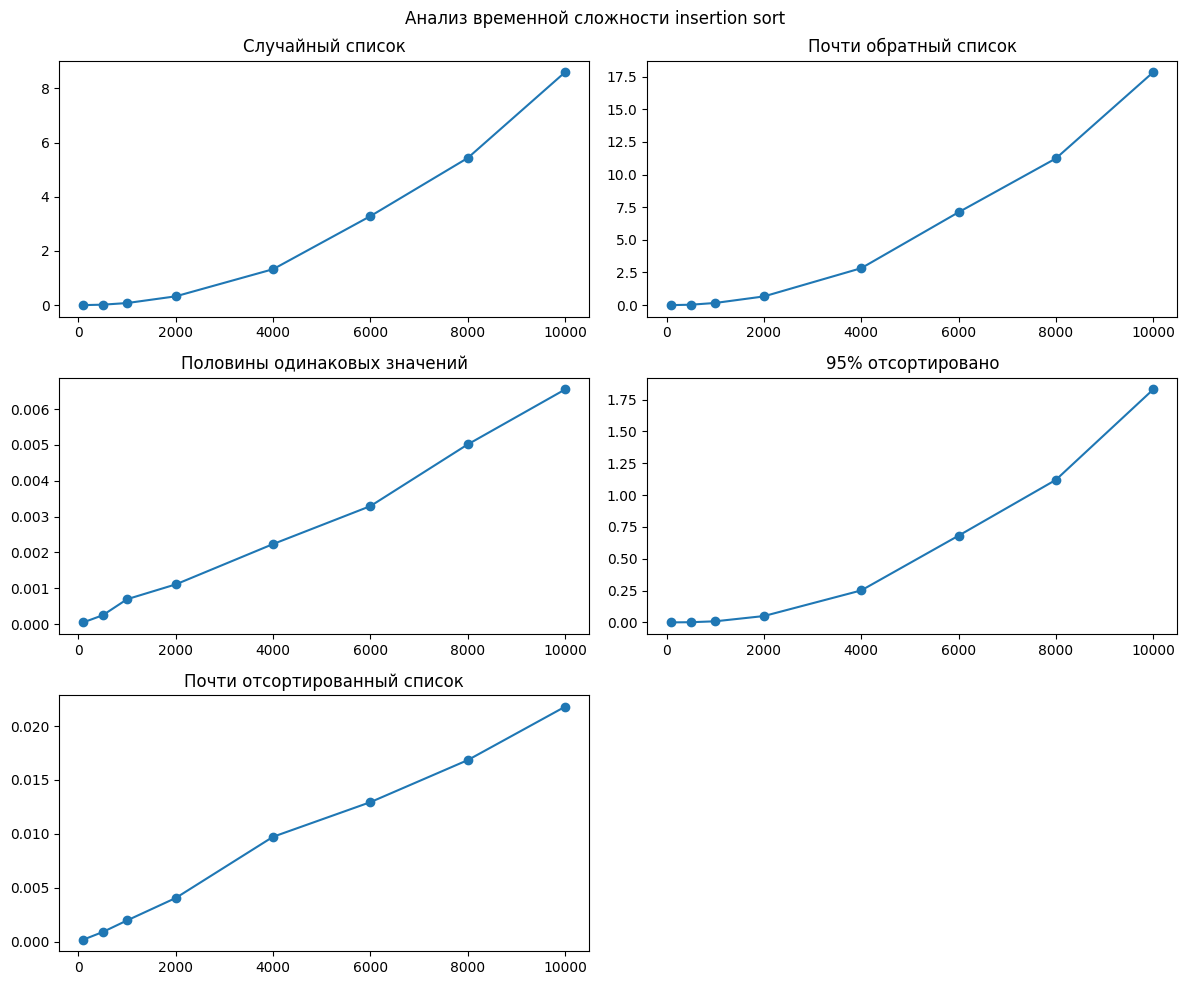

In [16]:
from matplotlib import pyplot as plt
import time
import random

def insertion_sort(some_list):
    for i in range(1, len(some_list)):
        for j in range(i, 0, -1):
            if some_list[j] < some_list[j - 1]:
                some_list[j - 1], some_list[j] = some_list[j], some_list[j-1]
            else:
                break
    return some_list

n = [100, 500, 1000, 2000, 4000, 6000, 8000, 10000]

def rand_list(n):
    return [random.randint(-100, 100) for _ in range(n)]

def almost_reverse_list(n):
    lst = list(range(n, 0, -1))  # полностью обратный список
    if n > 2:
        mid = n // 2
        lst[mid], lst[mid - 1] = lst[mid - 1], lst[mid]  # меняем местами два элемента
    return lst

def half_incremental_list(n):
    lst = []
    remaining = n
    value = 0
    while remaining > 0:
        take = max(1, remaining // 2)
        lst.extend([value] * take)
        remaining -= take
        value += 1
    return lst


def mostly_sorted_list(n, min_val=0, max_val=1000):
    sorted_part_size = int(n * 0.95)
    random_part_size = n - sorted_part_size
    lst = list(range(sorted_part_size))
    lst.extend([random.randint(min_val, max_val) for _ in range(random_part_size)])
    return lst

def nearly_sorted_list(n, max_displacement=10):
    lst = list(range(n))
    for i in range(n):
        swap_with = i + random.randint(-max_displacement, max_displacement)
        swap_with = max(0, min(n-1, swap_with))  # ограничиваем индекс
        lst[i], lst[swap_with] = lst[swap_with], lst[i]
    return lst


def measure_time(arr):
    start = time.perf_counter()
    insertion_sort(arr.copy())
    end = time.perf_counter()
    return end - start


rand_list_times = []
almost_reverse_list_times = []
half_incremental_list_times = []
mostly_sorted_list_times = []
nearly_sorted_list_times = []


for i in n:
    rand_list_times.append(measure_time(rand_list(i)))
    almost_reverse_list_times.append(measure_time(almost_reverse_list(i)))
    half_incremental_list_times.append(measure_time(half_incremental_list(i)))
    mostly_sorted_list_times.append(measure_time(mostly_sorted_list(i)))
    nearly_sorted_list_times.append(measure_time(nearly_sorted_list(i)))


fig, axes = plt.subplots(3, 2, figsize=(12, 10))

axes[0, 0].plot(n, rand_list_times, 'o-')
axes[0, 0].set_title('Случайный список')

axes[0, 1].plot(n, almost_reverse_list_times, 'o-')
axes[0, 1].set_title('Почти обратный список')

axes[1, 0].plot(n, half_incremental_list_times, 'o-')
axes[1, 0].set_title('Половины одинаковых значений')

axes[1, 1].plot(n, mostly_sorted_list_times, 'o-')
axes[1, 1].set_title('95% отсортировано')

axes[2, 0].plot(n, nearly_sorted_list_times, 'o-')
axes[2, 0].set_title('Почти отсортированный список')

axes[2, 1].axis('off')  # убираем пустой график

plt.suptitle('Анализ временной сложности insertion sort')
plt.tight_layout()
plt.show()


На каком из вариантов сортировка работает быстрее всего? На каком из вариантов – медленнее? Как вы можете это объяснить?


Быстрее всего работает на почти отсортированном списке и списком половины одинаковых значений
Здесь insertion sort работает почти за O(n).

Почти линейное время
Медленнее всего на почти полностью обратном списке almost_reverse_list
Это почти худший случай — O(n²).

Insertion sort:
Инверсия — пара элементов, стоящих не в том порядке.
Insertion sort быстрее всего работает там, где мало инверсий и много одинаковых элементов подряд.

5.  (6 баллов) Модифицируйте сортировку вставками, применив двоичный поиск места вставки нового элемента. Реализуйте модифицированный алгоритм в виде функции insertion_sort_with_bin_search(some_list). Функция принимает список и сортирует его по возрастанию.
Для этой функции выполните задание из пункта 4.
Есть ли отличие в результатах работы функций insertion_sort и insertion_sort_with_bin_search? Как вы можете это объяснить?
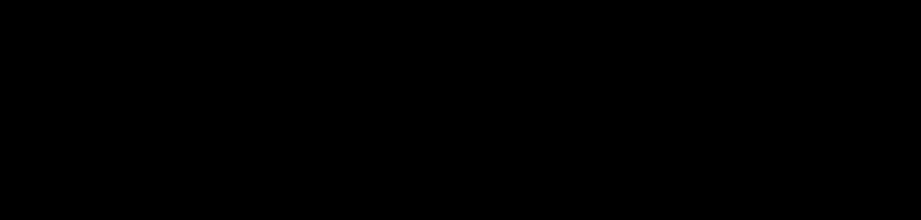

In [15]:
def insertion_sort_with_bin_search(some_list):
    for i in range(1, len(some_list)):
        key = some_list[i]

        # 1. бинарный поиск позиции
        left = 0
        right = i - 1
        while left <= right:
            mid = (left + right) // 2
            if key < some_list[mid]:
                right = mid - 1
            else:
                left = mid + 1

        # 2. сдвиг элементов вправо
        j = i
        while j > left:
            some_list[j] = some_list[j - 1]
            j -= 1

        # 3. вставка
        some_list[left] = key

    return some_list



insertion_sort_with_bin_search([3, 5, 2, 9, 8, 1, 6, 4, 7])

[1, 2, 3, 4, 5, 6, 7, 8, 9]

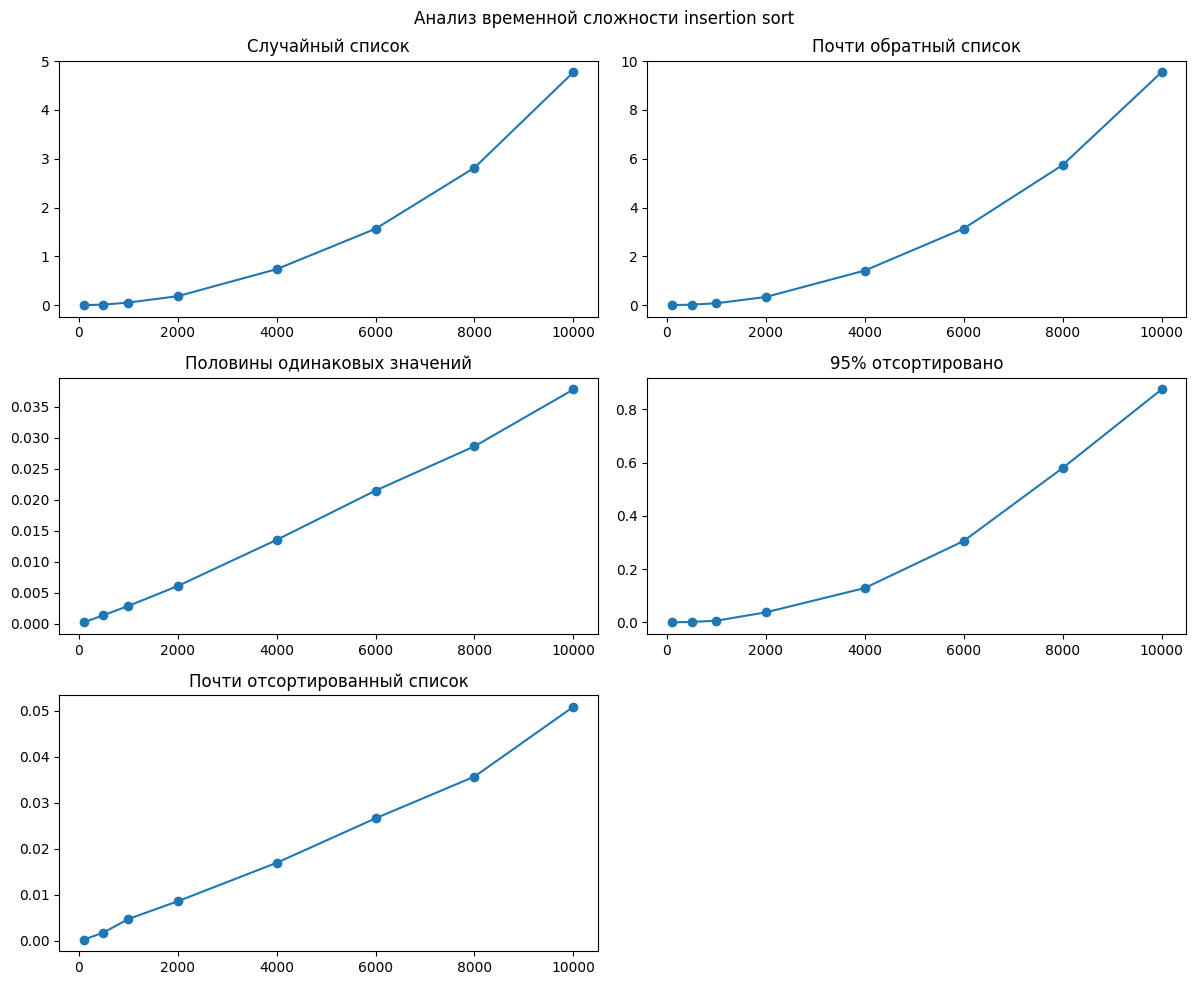

In [17]:
def measure_time(arr):
    start = time.perf_counter()
    insertion_sort_with_bin_search(arr.copy())
    end = time.perf_counter()
    return end - start


rand_list_times = []
almost_reverse_list_times = []
half_incremental_list_times = []
mostly_sorted_list_times = []
nearly_sorted_list_times = []


for i in n:
    rand_list_times.append(measure_time(rand_list(i)))
    almost_reverse_list_times.append(measure_time(almost_reverse_list(i)))
    half_incremental_list_times.append(measure_time(half_incremental_list(i)))
    mostly_sorted_list_times.append(measure_time(mostly_sorted_list(i)))
    nearly_sorted_list_times.append(measure_time(nearly_sorted_list(i)))


fig, axes = plt.subplots(3, 2, figsize=(12, 10))

axes[0, 0].plot(n, rand_list_times, 'o-')
axes[0, 0].set_title('Случайный список')

axes[0, 1].plot(n, almost_reverse_list_times, 'o-')
axes[0, 1].set_title('Почти обратный список')

axes[1, 0].plot(n, half_incremental_list_times, 'o-')
axes[1, 0].set_title('Половины одинаковых значений')

axes[1, 1].plot(n, mostly_sorted_list_times, 'o-')
axes[1, 1].set_title('95% отсортировано')

axes[2, 0].plot(n, nearly_sorted_list_times, 'o-')
axes[2, 0].set_title('Почти отсортированный список')

axes[2, 1].axis('off')  # убираем пустой график

plt.suptitle('Анализ временной сложности insertion sort')
plt.tight_layout()
plt.show()


* Обычный insertion_sort ищет место для вставки линейно (слева направо), что даёт O(n²) в худшем случае.
* insertion_sort_with_bin_search использует бинарный поиск для поиска позиции вставки, что снижает количество сравнений до O(n log n). Но сдвиги элементов всё равно выполняются линейно, поэтому асимптотически время всё ещё O(n²).

* Binary insertion sort чуть быстрее на больших данных, особенно если данные почти отсортированы или половина значений одинаковая.

* Для полностью случайных или почти обратных списков разница не так велика, так как основная нагрузка — сдвиг элементов, а не поиск позиции.

1. Почти отсортированные списки:

* Обычный insertion sort почти не делает сдвигов → очень быстро.
* Binary insertion sort тоже почти не делает сдвигов, плюс чуть быстрее поиск позиции → минимальное время.

2. Почти обратные списки:

* Большое количество сдвигов → обычный insertion sort медленно.
* Binary insertion sort экономит сравнения, но сдвиги остаются → немного быстрее обычного, но всё равно медленно.

3. Случайные списки:

* Сдвигов и сравнений достаточно много → разница между обычным и бинарным невелика.